<a href="https://colab.research.google.com/github/juuholiveira55-netizen/MVPMachineLearning/blob/main/MVP_ML_AVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome:** Juliana Barreto Oliveira  
**Matrícula:** 4052026000081
  
**Data:** 01/07/2026  
**Dataset:** Stroke Prediction Dataset — *healthcare-dataset-stroke-data.csv* ([fonte no GitHub](https://raw.githubusercontent.com/Saikrishna-89/STROKE-PREDICTION/main/healthcare-dataset-stroke-data.csv), dataset original no Kaggle)  
**Tipo de problema:** Classificação binária (prever ocorrência de AVC)

# MVP — Machine Learning & Analytics
### Previsão de risco de AVC a partir de dados clínicos e demográficos

Este notebook resolve um problema de classificação binária com classes desbalanceadas. A ideia foi montar um fluxo completo, entender o problema, olhar os dados com calma, preparar tudo sem vazamento, comparar alguns modelos contra um baseline ingênuo e discutir de forma crítica o que os números querem dizer num contexto de saúde.


### Checklist do MVP

| Item | Status |
|---|:---:|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste (estratificada) | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Mais de dois modelos comparados (além dos do template) | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

## 1. Definição do problema

### 1.1 Descrição do problema

O AVC (acidente vascular cerebral) está entre as principais causas de morte e de sequelas permanentes no mundo. A parte que interessa para este trabalho é que boa parte do risco está ligada a fatores que já são medidos numa consulta comum: idade, pressão alta, histórico de doença cardíaca, nível médio de glicose, índice de massa corporal e hábito de fumar.

A pergunta que quero responder é olhando para essas variáveis, dá para separar os pacientes com maior chance de AVC dos demais? A decisão que um modelo desses apoiaria não é "diagnosticar" — isso é papel do médico — e sim priorizar, quem necessitaria de uma avaliação mais atenta e exames adicionais.

Quem se beneficiaria: uma equipe de atenção primária ou um programa de triagem, que trabalha com fila e recursos limitados. Nesse cenário, deixar um caso de risco passar (falso negativo) é bem mais grave do que chamar alguém para um exame a mais (falso positivo).


### 1.2 Objetivo do MVP

Construir e avaliar modelos de classificação que estimem o risco de AVC a partir de variáveis clínicas e demográficas, comparando um baseline ingênuo com modelos candidatos e discutindo o compromisso entre capturar os casos positivos (recall) e não afogar a equipe em alarmes falsos (precisão).

### 1.3 Tipo de problema

Classificação binária.
A variável-alvo `stroke` assume apenas dois valores (0 = sem registro de AVC, 1 = com AVC).


### 1.4 Premissas, hipóteses e critérios de sucesso

**Hipotéses iniciais**

1. Idade e comorbidades (hipertensão, doença cardíaca) devem ser os fatores mais fortes. É o que a literatura médica sugere.
2. A base é desbalanceada, então acurácia vai enganar. Um modelo pode prever que "ninguém tem AVC" e já acertaria a maioria. Por isso a métrica principal não pode ser acurácia.
3. Um modelo linear simples pode competir de igual para igual com modelos mais complexos, porque as relações parecem ser em boa parte monotônicas (quanto mais velho, maior o risco).

**Critérios de sucesso:**
- Métrica principal: ROC AUC (mede a capacidade de ordenar risco, independente do limiar) somada ao recall da classe positiva (não deixar AVC passar). Uso Average Precision (PR AUC) como métrica de apoio, por ser mais informativa que a acurácia quando a classe positiva é rara.
- Resultado mínimo aceitável: superar com folga o baseline (AUC 0,50) e alcançar AUC > 0,75.
- Restrição prática: entre modelos de desempenho parecido, prefiro o mais simples, rápido e interpretável num contexto clínico, poder explicar por que um paciente foi sinalizado pode salvar uma vida.

## 2. Ambiente, bibliotecas e reprodutibilidade

Importei só o que realmente uso e fixei a seed em todos os pontos que envolvem sorteio (divisão dos dados, floresta aleatória, busca de hiperparâmetros).


In [12]:
# === Setup e reprodutibilidade ===
import time
INICIO = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      RandomizedSearchCV, cross_val_predict,
                                      cross_val_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve)
from scipy.stats import randint, loguniform

import sklearn
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Versões usadas nesta execução:")
print("  pandas      :", pd.__version__)
print("  numpy       :", np.__version__)
print("  scikit-learn:", sklearn.__version__)
print("  seed fixa   :", SEED)

Versões usadas nesta execução:
  pandas      : 2.2.2
  numpy       : 2.0.2
  scikit-learn: 1.6.1
  seed fixa   : 42


## 3. Seleção e carga dos dados

### 3.1 Fonte dos dados

Usei o Stroke Prediction Dataset, uma base pública com pouco mais de 5 mil registros de pacientes e informações clínicas/demográficas rotuladas com a ocorrência ou não de AVC. Escolhi essa base pelos motivos: (1) é um problema com significado real e fácil de contar como história; (2) tem uma mistura boa de variáveis numéricas e categóricas

Sobre ética e privacidade: os dados são anônimos (não há nome, documento ou endereço) e distribuídos publicamente para fins de estudo. Ainda assim, tratei a variável de risco com cautela na conclusão, porque um modelo de saúde treinado numa base pequena e enviesada não deve ser usado para decisão clínica real.

Link da fonte: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

### 3.2 Carga dos dados



In [4]:
import pandas as pd
# === Carga dos dados ===
import pandas as pd
URL_DADOS = "https://raw.githubusercontent.com/juuholiveira55-netizen/MVPMachineLearning/refs/heads/main/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(URL_DADOS)
print("Dados carregados com sucesso:", df.shape[0], "linhas x", df.shape[1], "colunas")
df.head()

Dados carregados com sucesso: 5110 linhas x 12 colunas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 3.3 Visão geral do dataset



In [14]:
print("Formato:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nLinhas duplicadas:", df.duplicated().sum())

Formato: (5110, 12)

Tipos de dados:


,tipo
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64



Valores ausentes por coluna:


,ausentes
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201



Linhas duplicadas: 0


In [15]:
for col in ["gender", "smoking_status", "work_type", "ever_married", "Residence_type"]:
    print(f"{col}:")
    print(df[col].value_counts().to_string())
    print()

gender:
gender
Female    2994
Male      2115
Other        1

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22

ever_married:
ever_married
Yes    3353
No     1757

Residence_type:
Residence_type
Urban    2596
Rural    2514



In [16]:
# === Limpeza inicial ===
df = df.drop(columns=["id"])                       # identificador, sem valor preditivo
antes = len(df)
df = df[df["gender"] != "Other"].copy()            # remove o único registro 'Other'
print(f"Removido registro gender='Other': {antes - len(df)} linha. Base agora: {df.shape}")

Removido registro gender='Other': 1 linha. Base agora: (5109, 11)


### 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Entra no modelo? | Observação |
|---|---|---|:---:|---|
| `gender` | categórica | Sexo (Male/Female) | Sim | categoria `Other` (n=1) removida |
| `age` | numérica | Idade em anos (0.08 a 82) | Sim | inclui bebês/crianças |
| `hypertension` | binária | 1 = tem hipertensão | Sim | fator de risco clássico |
| `heart_disease` | binária | 1 = tem doença cardíaca | Sim | fator de risco clássico |
| `ever_married` | categórica | Já foi casado (Yes/No) | Sim | provavelmente confundida com idade |
| `work_type` | categórica | Tipo de trabalho | Sim | inclui `children`, `Never_worked` |
| `Residence_type` | categórica | Zona urbana/rural | Sim | esperava pouco efeito |
| `avg_glucose_level` | numérica | Glicose média no sangue | Sim | proxy de diabetes |
| `bmi` | numérica | Índice de massa corporal | Sim | 201 ausentes → imputação |
| `bmi_faltante` | binária | **Criada por mim**: 1 se `bmi` estava ausente | Sim | ver seção 4.1 / 6.2 |
| `stroke` | **alvo** | 1 = teve AVC | — | classe positiva ≈ 4,9% |

## 4. Análise exploratória dos dados



Distribuição do alvo (stroke):


,contagem,percentual
stroke,,
0,4860,95.1300
1,249,4.8700


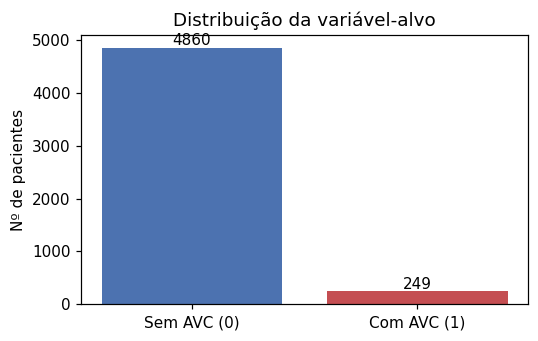

In [17]:
dist = df["stroke"].value_counts().sort_index()
perc = (df["stroke"].value_counts(normalize=True).sort_index() * 100).round(2)
print("Distribuição do alvo (stroke):")
display(pd.concat([dist.rename("contagem"), perc.rename("percentual")], axis=1))

plt.figure(figsize=(5, 3.2))
plt.bar(["Sem AVC (0)", "Com AVC (1)"], dist.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(dist.values):
    plt.text(i, v + 40, str(v), ha="center")
plt.title("Distribuição da variável-alvo")
plt.ylabel("Nº de pacientes")
plt.tight_layout(); plt.show()

Só ~4,9% dos pacientes tiveram AVC. Um classificador que responde sempre "não teve AVC" acerta ~95% das vezes, mas não é muito útil. Isso confirma a hipótese 2, em relação a decisão de não usar acurácia como métrica principal, e sim ROC AUC, recall e Average Precision.

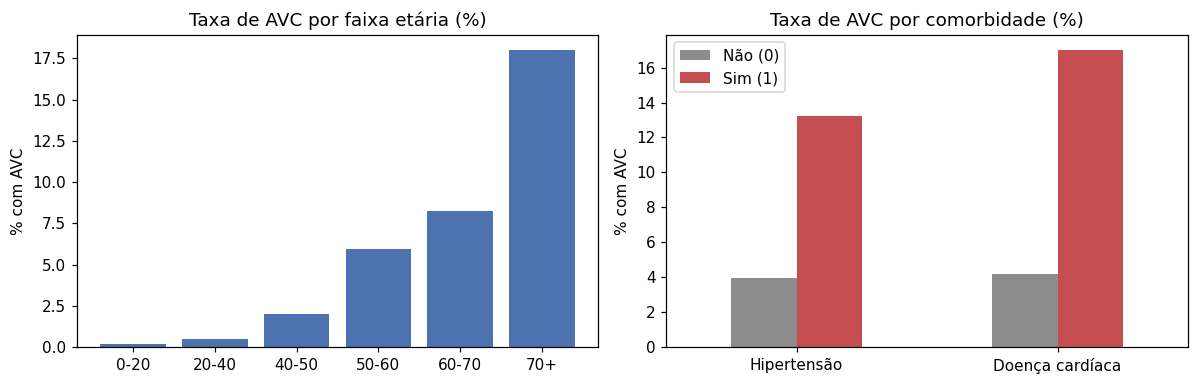

In [18]:
# Relação das variáveis contínuas e binárias com a taxa de AVC
faixa = pd.cut(df["age"], [0, 20, 40, 50, 60, 70, 120],
               labels=["0-20", "20-40", "40-50", "50-60", "60-70", "70+"])
taxa_idade = df.groupby(faixa, observed=True)["stroke"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(taxa_idade.index.astype(str), taxa_idade.values, color="#4C72B0")
ax[0].set_title("Taxa de AVC por faixa etária (%)"); ax[0].set_ylabel("% com AVC")

taxa_comorb = pd.DataFrame({
    "Hipertensão": df.groupby("hypertension")["stroke"].mean() * 100,
    "Doença cardíaca": df.groupby("heart_disease")["stroke"].mean() * 100,
}).T
taxa_comorb.columns = ["Não (0)", "Sim (1)"]
taxa_comorb.plot(kind="bar", ax=ax[1], color=["#8C8C8C", "#C44E52"])
ax[1].set_title("Taxa de AVC por comorbidade (%)"); ax[1].set_ylabel("% com AVC")
ax[1].set_xticklabels(taxa_comorb.index, rotation=0)
plt.tight_layout(); plt.show()

A taxa de AVC sai de 0,2% abaixo dos 20 anos para ~18% acima dos 70, idade é o fator mais forte. Hipertensão (13% vs 4%) e doença cardíaca (17% vs 4%) também multiplicam o risco por três ou quatro vezes.

Uma ressalva: variáveis como `ever_married` também mostram taxa mais alta (6,6% vs 1,7%), mas isso pode ser um efeito de confusão com a idade, quem é casado tende a ser mais velho. Não é o casamento que causa AVC; é a idade por trás dele.

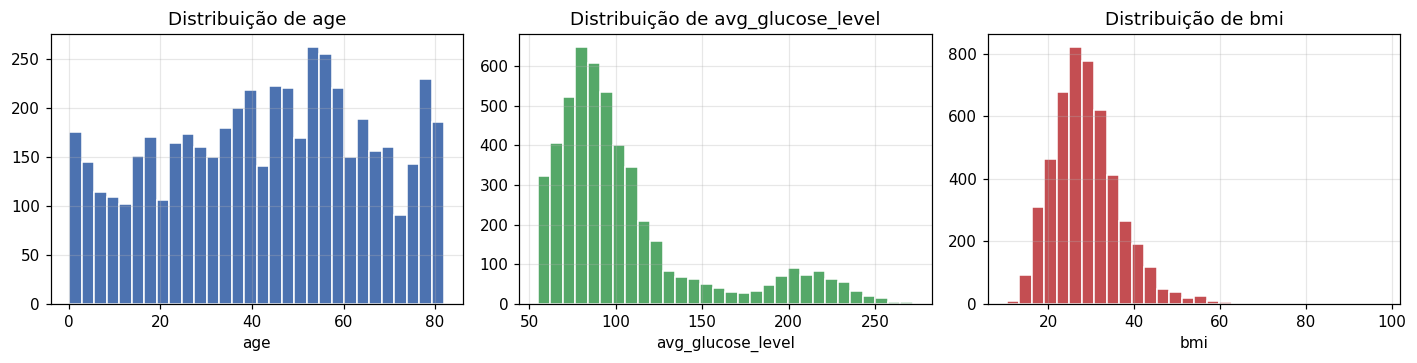

In [19]:
# Distribuição das variáveis numéricas contínuas
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, col, cor in zip(ax, ["age", "avg_glucose_level", "bmi"], ["#4C72B0", "#55A868", "#C44E52"]):
    df[col].hist(bins=30, ax=a, color=cor, edgecolor="white")
    a.set_title(f"Distribuição de {col}"); a.set_xlabel(col); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

A idade se espalha por toda a faixa (a base tem desde bebês até idosos). A glicose é bem assimétrica à direita, com um segundo grupo lá em cima na faixa diabética (>160), que na análise por faixas mostrou taxa de AVC de ~13% contra ~3,5% nas demais. O BMI tem uma distribuição razoavelmente normal com alguns outliers altos. Como essas escalas são muito diferentes entre si, padronizei as numéricas antes dos modelos sensíveis a escala (regressão logística e KNN).

In [20]:
# A "surpresa" do BMI: a AUSÊNCIA do valor é aleatória?
df["_bmi_ausente"] = df["bmi"].isna()
tx = df.groupby("_bmi_ausente")["stroke"].agg(taxa_avc=lambda s: s.mean()*100, n="size").round(2)
tx.index = ["BMI presente", "BMI ausente"]
print("Taxa de AVC conforme o BMI está ausente ou não:")
display(tx)
df = df.drop(columns=["_bmi_ausente"])

Taxa de AVC conforme o BMI está ausente ou não:


,taxa_avc,n
BMI presente,4.2600,4908
BMI ausente,19.9000,201


Quando o BMI está ausente, a taxa de AVC é de quase 20% — contra ~4% quando ele está presente. Ou seja, o valor faltante não falta ao acaso: pacientes que tiveram AVC (muitas vezes casos graves ou fatais) têm bem mais chance de estar com o BMI em branco.

A consequência prática é importante: se eu simplesmente imputar a mediana e seguir em frente, jogo fora essa informação. Então decidi criar uma variável indicadora `bmi_faltante` que marca se o BMI estava vazio.

### 4.1 Síntese da análise exploratória

Resumo do que a EDA mostrou e como isso influênciou nas próximas fases:

- Alvo desbalanceado (~4,9%) → foco em ROC AUC, recall e Average Precision; uso de  `class_weight="balanced"` nos modelos que suportam.
- Idade é o fator dominante, seguida de comorbidades e glicose alta → relações fortes e majoritariamente monotônicas, o que favorece até modelos lineares.
- Escalas muito diferentes entre idade, glicose e BMI → padronização das numéricas.
- `bmi` com 201 ausentes, e a ausência é informativa (MNAR) → imputo a mediana e crio o indicador `bmi_faltante`.
- `smoking_status='Unknown'` e `gender='Other'` (n=1) → mantenho `Unknown` como categoria; removo o `Other`.
- `ever_married` provavelmente é confundida com idade → mantenho a variável.

## 5. Preparação dos dados e divisão treino/teste

Aqui eu crio a feature `bmi_faltante`, separo features e alvo e faço a divisão.

P.S.: crio `bmi_faltante` a partir da presença/ausência do próprio valor, linha a linha. Isso não usa o alvo e nem estatística do conjunto todo, então não gera vazamento — o indicador estaria disponível na hora real da previsão (o sistema sabe se o BMI foi ou não preenchido).

In [21]:
# Feature de engenharia motivada pela EDA
df["bmi_faltante"] = df["bmi"].isna().astype(int)

TARGET = "stroke"
num_cols = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease", "bmi_faltante"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

features = num_cols + bin_cols + cat_cols
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print(f"Positivos no treino: {y_train.sum()} ({y_train.mean()*100:.1f}%) | "
      f"no teste: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Treino: (4087, 11) | Teste: (1022, 11)
Positivos no treino: 199 (4.9%) | no teste: 50 (4.9%)


### 5.1 Justificativa da divisão

Usei holdout estratificado 80/20.

- Estratificação pelo alvo é obrigatória aqui. Com apenas ~5% de positivos, uma divisão aleatória comum poderia concentrar os poucos casos de AVC de um lado só. O `stratify=y` garante a mesma proporção ( ~4,9%) em treino e teste.
- Prevenção de vazamento: todas as transformações que aprendem parâmetros (mediana da imputação, média/desvio da padronização, categorias do one-hot) ficam dentro de um `Pipeline` e são ajustadas apenas no treino. O teste é tocado apenas no final. Além disso, na hora de escolher o limiar de decisão, uso validação cruzada dentro do treino, e não o teste.
- Uso validação cruzada estratificada (5 folds) para a busca de hiperparâmetros e para o ajuste de threshold, porque com tão poucos positivos uma única partição de validação seria instável demais.

## 6. Pré-processamento e pipeline

Montei o pré-processamento como um `ColumnTransformer` dentro de um `Pipeline`.

In [35]:
# Numéricas: imputa mediana (robusta a outliers) + padroniza
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categóricas: imputa moda + one-hot (ignora categorias novas)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("bin", "passthrough", bin_cols),
    ("cat", categorical_pipe, cat_cols),
])
print("Numéricas :", num_cols)
print("Binárias  :", bin_cols)
print("Categóricas:", cat_cols)

Numéricas : ['age', 'avg_glucose_level', 'bmi']
Binárias  : ['hypertension', 'heart_disease', 'bmi_faltante']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [23]:
# Numéricas: imputa mediana (robusta a outliers) + padroniza
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categóricas: imputa moda + one-hot (ignora categorias novas)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("bin", "passthrough", bin_cols),   # já são 0/1
    ("cat", categorical_pipe, cat_cols),
])
print("Numéricas :", num_cols)
print("Binárias  :", bin_cols)
print("Categóricas:", cat_cols)

Numéricas : ['age', 'avg_glucose_level', 'bmi']
Binárias  : ['hypertension', 'heart_disease', 'bmi_faltante']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### 6.1 Decisões de pré-processamento

- Imputação por mediana no BMI (única numérica com falta): a mediana é mais robusta aos outliers altos que vi no histograma do que a média.
- Padronização (StandardScaler) nas contínuas: idade, glicose e BMI vivem em escalas muito diferentes; sem padronizar, a regressão logística e o KNN dariam peso desproporcional à glicose só por ela ter números maiores. Mantive um pre-processamento para todos
- One-hot com `handle_unknown="ignore"`: se aparecer no teste uma categoria que não existia no treino, o encoder gera um vetor de zeros em vez de quebrar.
- `hypertension`, `heart_disease` e `bmi_faltante` passam direto(`passthrough`): já são binárias.

### 6.2 A feature `bmi_faltante` se justifica de fato?

Confirmação de que a criação de uma variável foi necessária, utilizei ela com validação cruzada no treino.
Num primeiro momento ela parece que piorao Average Precision. Refazendo com validação cruzada o quadro se inverteu.

In [36]:
# Comparação: logística com vs sem 'bmi_faltante'
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def monta_logistica(usar_indicador):
    bins = ["hypertension", "heart_disease"] + (["bmi_faltante"] if usar_indicador else [])
    pre = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("bin", "passthrough", bins),
        ("cat", categorical_pipe, cat_cols),
    ])
    return Pipeline([("pre", pre),
                     ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                   random_state=SEED))])

for rotulo, flag in [("SEM bmi_faltante", False), ("COM bmi_faltante", True)]:
    ap = cross_val_score(monta_logistica(flag), X_train, y_train, cv=cv, scoring="average_precision")
    auc = cross_val_score(monta_logistica(flag), X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{rotulo:18s} | AP(cv) = {ap.mean():.4f} ± {ap.std():.4f} | "
          f"ROC AUC(cv) = {auc.mean():.4f} ± {auc.std():.4f}")

SEM bmi_faltante   | AP(cv) = 0.1921 ± 0.0437 | ROC AUC(cv) = 0.8389 ± 0.0196
COM bmi_faltante   | AP(cv) = 0.2246 ± 0.0378 | ROC AUC(cv) = 0.8537 ± 0.0238


Confirmado: com o indicador, tanto o Average Precision quanto o ROC AUC sobem de forma consistente na validação cruzada. Mantenho a feature no conjunto final.
Com isso podemos perceber que não dá pra decidir a inclusão de uma variável com apenas um split de teste.

## 7. Baseline e modelos candidatos

Defini um baseline neutro e quatro modelos candidatos. O template já trazia Regressão Logística e Random Forest, acrescentei HistGradientBoosting e KNN.

In [25]:
baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent")),  # sempre prevê a classe majoritária
])

candidatos = {
    "Regressao Logistica": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                          random_state=SEED, n_jobs=1)),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocess", preprocess),
        ("model", HistGradientBoostingClassifier(random_state=SEED)),
    ]),
    "KNN (k=15)": Pipeline([
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier(n_neighbors=15)),
    ]),
}
print("Baseline :", "DummyClassifier (classe mais frequente)")
print("Candidatos:", list(candidatos.keys()))

Baseline : DummyClassifier (classe mais frequente)
Candidatos: ['Regressao Logistica', 'Random Forest', 'HistGradientBoosting', 'KNN (k=15)']


### 7.1 Justificativa dos modelos

- Baseline — `DummyClassifier(most_frequent)`: prevê sempre "sem AVC". Os outros modelos precisa ganhar dele nas métricas que importam.
- Regressão Logística (`class_weight="balanced"`): linear, rápida e interpretável (dá coeficientes). Como a EDA sugeriu relações monotônicas, é uma aposta forte. O `class_weight` compensa o desbalanceamento penalizando mais os erros na classe rara.
- Random Forest (`balanced`): captura interações e não linearidades sem exigir escala; boa referência não linear.
- HistGradientBoosting: o modelo "pesado" da lista — boosting costuma ser o estado da arte em dados tabulares.
- KNN (k=15): uma lógica bem diferente. Usei k grande para suavizar numa base ruidosa. Sensível a escala.



## 8. Treinamento e avaliação inicial

Criei uma função para calcular sempre o mesmo conjunto de métricas e evitar repetição. Além da acurácia (para mostrar como ela engana), calculo recall, precisão e F1 da classe positiva, ROC AUC e Average Precision.

In [26]:
def avalia_classificacao(nome, modelo, X_te, y_te, tempo_treino):
    y_pred = modelo.predict(X_te)
    proba = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, "predict_proba") else None
    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_te, y_pred),
        "recall (AVC)": recall_score(y_te, y_pred, zero_division=0),
        "precisao (AVC)": precision_score(y_te, y_pred, zero_division=0),
        "f1 (AVC)": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba) if proba is not None else np.nan,
        "avg_precision": average_precision_score(y_te, proba) if proba is not None else np.nan,
        "tempo_treino_s": round(tempo_treino, 3),
    }

In [27]:
resultados = []

t0 = time.time(); baseline.fit(X_train, y_train)
resultados.append(avalia_classificacao("Baseline (mais frequente)", baseline,
                                        X_test, y_test, time.time() - t0))

modelos_treinados = {}
for nome, mdl in candidatos.items():
    t0 = time.time(); mdl.fit(X_train, y_train)
    resultados.append(avalia_classificacao(nome, mdl, X_test, y_test, time.time() - t0))
    modelos_treinados[nome] = mdl

tabela = pd.DataFrame(resultados).set_index("modelo").sort_values("roc_auc", ascending=False)
display(tabela.style.format("{:.4f}", subset=tabela.columns[:-1])
             .background_gradient(cmap="Greens", subset=["roc_auc", "avg_precision"]))

,acuracia,recall (AVC),precisao (AVC),f1 (AVC),roc_auc,avg_precision,tempo_treino_s
modelo,,,,,,,
Regressao Logistica,0.7534,0.8000,0.1418,0.2410,0.8373,0.2273,0.213000
HistGradientBoosting,0.9432,0.0400,0.1667,0.0645,0.7988,0.1723,0.894000
Random Forest,0.9501,0.0000,0.0000,0.0000,0.7851,0.1480,3.730000
KNN (k=15),0.9511,0.0000,0.0000,0.0000,0.7432,0.1368,0.083000
Baseline (mais frequente),0.9511,0.0000,0.0000,0.0000,0.5000,0.0489,0.056000


### 8.1 Análise dos resultados iniciais

Com os resultados iniciais podemos ver que:
A acurácia não pode ser usada de base. O baseline tem ~95% de acurácia e é inútil: recall e F1 da classe positiva zerados, AUC 0,50. Random Forest e KNN também batem ~95% de acurácia mas com recall zero, no limiar padrão de 0,5, eles simplesmente não sinalizam quase nenhum AVC.
A Regressão Logística é a melhor: ROC AUC ≈ 0,84 e Average Precision ≈ 0,23 (contra 0,05 do baseline), além de um recall de 0,80, ela captura 4 em cada 5 casos de AVC.
Random Forest, HistGradientBoosting e KNN, apesar de AUCs razoáveis (0,74–0,80), ficam atrás do modelo linear. Isso é coerente com a EDA: os fatores de risco agem de forma bastante monotônica, terreno onde um modelo linear faz sentido.
Sinais de underfitting/threshold ruim nas árvores, o recall ~0 de RF e KNN no limiar 0,5 não é bem underfitting — a AUC decente mostra que eles ordenam o risco de forma razoável, mas o limiar de 0,5 é inadequado para uma classe tão rara.
Os tempos de treino são todos baixos.

## 9. Otimização de hiperparâmetros

Fiz uma busca aleatória (`RandomizedSearchCV`) no HistGradientBoosting é o candidato sofisticado da lista, o que teria mais a ganhar com ajuste fino. A pergunta que quero responder é "dando a chance justa de calibrar o boosting, ele consegue ultrapassar a logística simples?".

Otimizei pela Average Precision, que é a métrica sensível à classe rara, com validação cruzada estratificada de 5 folds, tudo dentro do treino.

In [28]:
espaco = {
    "model__learning_rate":   loguniform(0.01, 0.3),
    "model__max_leaf_nodes":  randint(8, 64),
    "model__min_samples_leaf": randint(10, 60),
    "model__l2_regularization": loguniform(1e-3, 10),
    "model__max_iter":        randint(100, 400),
}
hgb_base = Pipeline([("preprocess", preprocess),
                     ("model", HistGradientBoostingClassifier(random_state=SEED))])

busca = RandomizedSearchCV(hgb_base, espaco, n_iter=20, cv=cv,
                           scoring="average_precision", random_state=SEED, n_jobs=1)
t0 = time.time(); busca.fit(X_train, y_train)
print(f"Busca concluída em {time.time()-t0:.1f}s")
print("Melhor AP na validação cruzada:", round(busca.best_score_, 4))
print("Melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"   {k} = {round(v, 4) if isinstance(v, float) else v}")

hgb_otimizado = busca.best_estimator_
proba_hgb = hgb_otimizado.predict_proba(X_test)[:, 1]
print("\nHistGB otimizado no TESTE -> ROC AUC:", round(roc_auc_score(y_test, proba_hgb), 4),
      "| AP:", round(average_precision_score(y_test, proba_hgb), 4))

Busca concluída em 117.3s
Melhor AP na validação cruzada: 0.2252
Melhores hiperparâmetros:
   model__l2_regularization = 0.0046
   model__learning_rate = 0.0105
   model__max_iter = 108
   model__max_leaf_nodes = 31
   model__min_samples_leaf = 10

HistGB otimizado no TESTE -> ROC AUC: 0.809 | AP: 0.2098


### 9.1 Discussão da otimização

O ajuste melhorou o HistGradientBoosting: o Average Precision na validação cruzada subiu de ~0,17 para ~0,22, e os hiperparâmetros escolhidos fazem sentido `learning_rate` baixo com muitas iterações e `min_samples_leaf` alto formam um modelo mais regularizado, coerente com uma base pequena e ruidosa.

Mas mesmo otimizado, ele ainda não ultrapassa a Regressão Logística no teste (AUC do HGB ~0,81 contra ~0,84 da logística; AP na mesma faixa).

## 10. Avaliação final no conjunto de teste

Modelo escolhido foi **Regressão Logística**

O limiar padrão de 0,5 quase nunca é o certo para classe rara. Em vez de escolhê-lo olhando o teste, estimo o melhor limiar usando previsões out-of-fold por validação cruzada no treino, e só depois aplico esse limiar fixo ao teste.

In [29]:
modelo_final = modelos_treinados["Regressao Logistica"]
proba_teste = modelo_final.predict_proba(X_test)[:, 1]

# Limiar estimado SEM olhar o teste: previsões out-of-fold no treino
proba_oof = cross_val_predict(modelo_final, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, proba_oof)
f1_por_thr = 2 * prec * rec / (prec + rec + 1e-9)
melhor_i = int(np.nanargmax(f1_por_thr[:-1]))
limiar_otimo = thr[melhor_i]
print(f"Limiar que maximiza o F1 (estimado no treino via CV): {limiar_otimo:.3f}")

Limiar que maximiza o F1 (estimado no treino via CV): 0.733


=== Regressão Logística no TESTE ===
ROC AUC: 0.8373 | Average Precision: 0.2273



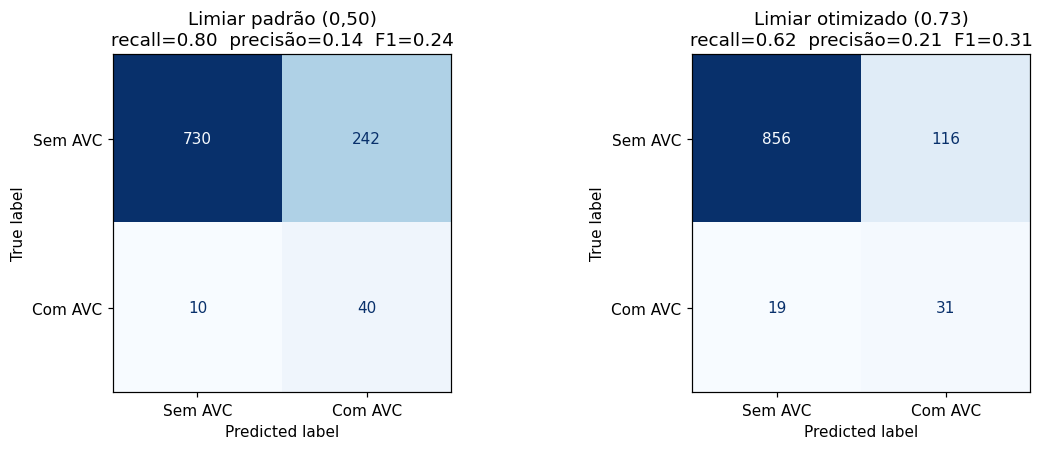


Relatório de classificação (limiar padrão 0,50):
              precision    recall  f1-score   support

     Sem AVC       0.99      0.75      0.85       972
     Com AVC       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022



In [30]:
# Comparação dos dois limiares no conjunto de teste
print("=== Regressão Logística no TESTE ===")
print(f"ROC AUC: {roc_auc_score(y_test, proba_teste):.4f} | "
      f"Average Precision: {average_precision_score(y_test, proba_teste):.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, t, titulo in [(axes[0], 0.50, "Limiar padrão (0,50)"),
                      (axes[1], limiar_otimo, f"Limiar otimizado ({limiar_otimo:.2f})")]:
    y_hat = (proba_teste >= t).astype(int)
    cm = confusion_matrix(y_test, y_hat)
    ConfusionMatrixDisplay(cm, display_labels=["Sem AVC", "Com AVC"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{titulo}\nrecall={recall_score(y_test, y_hat):.2f}  "
                 f"precisão={precision_score(y_test, y_hat, zero_division=0):.2f}  "
                 f"F1={f1_score(y_test, y_hat):.2f}")
plt.tight_layout(); plt.show()

print("\nRelatório de classificação (limiar padrão 0,50):")
print(classification_report(y_test, (proba_teste >= 0.5).astype(int),
                            target_names=["Sem AVC", "Com AVC"], zero_division=0))

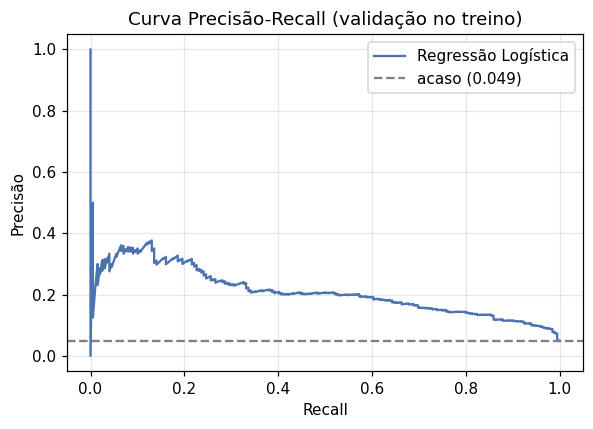

In [31]:
# Curva Precision-Recall
plt.figure(figsize=(5.5, 4))
plt.plot(rec, prec, color="#4C72B0", label="Regressão Logística")
plt.axhline(y_train.mean(), ls="--", color="gray", label=f"acaso ({y_train.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precisão")
plt.title("Curva Precisão-Recall (validação no treino)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

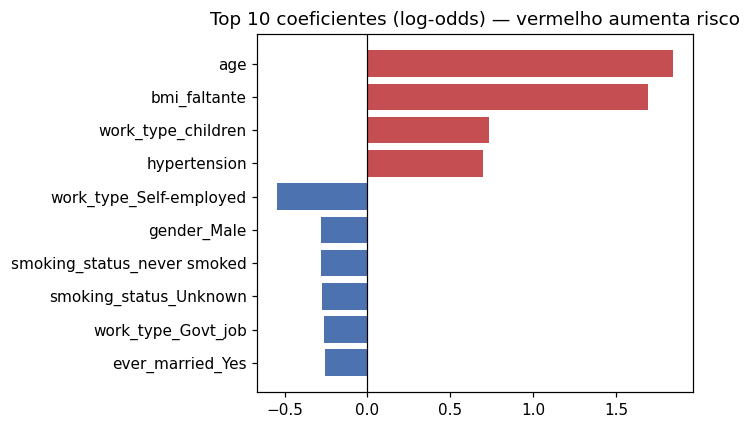

In [32]:
# Interpretabilidade: quais variáveis mais pesam na logística
nomes = modelo_final.named_steps["preprocess"].get_feature_names_out()
nomes = [n.split("__", 1)[-1] for n in nomes]  # tira o prefixo do ColumnTransformer
coefs = pd.Series(modelo_final.named_steps["model"].coef_[0], index=nomes)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(6.5, 4))
cores = ["#C44E52" if v > 0 else "#4C72B0" for v in top.values]
plt.barh(top.index[::-1], top.values[::-1], color=cores[::-1])
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 10 coeficientes (log-odds) — vermelho aumenta risco")
plt.tight_layout(); plt.show()

### 10.1 Análise de erros e limitações

No limiar padrão (0,50), o modelo captura 40 dos 50 AVCs do teste, ao custo de muitos falsos positivos (precisão ~0,14). Subindo o limiar para ~0,73, a precisão melhora ( ~0,21) mas o recall cai para 0,62.

Não existe limiar certo ele depende do custo relativo dos erros.

 Para uma ferramenta de triagem, defendo o limiar mais baixo (mais recall). Um falso positivo custa um exame extra; um falso negativo é um AVC não sinalizado. Nesse contexto, os 40 casos capturados valem os alarmes falsos.

Que erros o modelo comete mais? Falsos positivos, de longe, é o efeito esperado de um modelo `balanced` com limiar baixo numa classe rara. Os falsos negativos tendem a ser pacientes mais jovens e sem comorbidades óbvias, justamente os casos que qualquer regra baseada em fatores de risco erraria.

Overfitting ou underfitting? Não há sinal de overfitting: o desempenho na validação cruzada (AP ~0,19–0,22) é coerente com o do teste, e o modelo linear é simples. Se algo, o teto de ~0,84 de AUC sugere que estamos mais perto de um limite de informação (as variáveis disponíveis só explicam parte do risco) do que de um problema de capacidade do modelo.

Sobre os coeficientes: idade e o indicador `bmi_faltante` dominam, seguidos de hipertensão — coerente com a EDA e com a medicina.

Limitações honestas:
Só 50 casos positivos no teste qualquer métrica tem um intervalo de confiança largo.
O `bmi_faltante` é poderoso, mas seu sinal (BMI faltar em casos graves) pode ser um artefato de como a base foi coletada, e não algo que se repetiria em produção. .
A base é transversal (uma foto no tempo), então não há como saber se o fator "veio antes" do AVC. O modelo mede associação.
Em que cenário não usar: jamais para decisão clínica individual ou para negar atendimento.

## 11. Comparação final dos modelos

Síntese:

| Modelo | ROC AUC | Avg. Precision | Recall (AVC) | Precisão (AVC) | Tempo treino | Observação |
|---|:---:|:---:|:---:|:---:|:---:|---|
| Baseline (mais frequente) | 0,50 | 0,05 | 0,00 | 0,00 | ~0,02 s | inútil, mas expõe a armadilha da acurácia |
| **Regressão Logística** (limiar 0,50) | **≈0,84** | **≈0,23** | **0,80** | 0,14 | ~0,02 s | **melhor no geral, simples e interpretável** |
| Regressão Logística (limiar ~0,73) | ≈0,84 | ≈0,23 | 0,62 | 0,21 | — | opção com menos falsos positivos |
| Random Forest | ≈0,79 | ≈0,15 | 0,00* | 0,00* | ~1 s | *recall zero no limiar 0,50 |
| HistGradientBoosting (otimizado) | ≈0,81 | ≈0,21 | — | — | busca ~50 s | melhorou com tuning, mas não superou a logística |
| KNN (k=15) | ≈0,74 | ≈0,14 | 0,00* | 0,00* | ~0,02 s | pior AUC; *recall zero no limiar 0,50 |

O modelo final é a **Regressão Logística**: melhor capacidade de ordenar risco (AUC), melhor Average Precision, o único a capturar a classe positiva no limiar padrão, além de ser o mais rápido e o único que entrega coeficientes interpretáveis.

## 12. Boas práticas e rastreabilidade

Reprodutibilidade:`SEED = 42` fixada e propagada para a divisão dos dados, os modelos aleatórios e a busca de hiperparâmetros. Bibliotecas usadas: pandas, numpy, scikit-learn, scipy e matplotlib.

**Registro das principais decisões:**

| Decisão | Justificativa | Impacto |
|---|---|---|
| Métrica principal = ROC AUC + recall (não acurácia) | classe positiva ~4,9% | evita escolher um modelo "de 95%" que não detecta AVC |
| `class_weight="balanced"` | desbalanceamento | modelos passam a "enxergar" a classe rara |
| Criar `bmi_faltante` | ausência de BMI associada a AVC (MNAR) | ganho em AP/AUC confirmado por CV |
| Remover `gender='Other'` | n=1, sem valor de aprendizado | limpeza sem perda relevante |
| Manter `smoking_status='Unknown'` como categoria | imputar 30% da base injetaria viés | preserva possível sinal da própria ausência |
| Ajustar limiar via CV out-of-fold | escolher limiar no teste seria vazamento | avaliação final honesta |
| Escolher a Logística | empata/supera as ensembles sendo mais simples | interpretabilidade e baixo custo |
| Descartado: SMOTE / busca maior | pouco retorno esperado para um MVP | mantém o projeto enxuto |

## 13. Conclusão

O objetivo era construir e avaliar modelos que estimassem o risco de AVC a partir de dados clínicos e demográficos, com foco em capturar os casos positivos sem se deixar enganar pela acurácia. Acho que o MVP cumpriu isso.

Comecei confirmando, na EDA, que a idade domina o risco, seguida de hipertensão, doença cardíaca e glicose alta — e tropecei num achado que não esperava: **a ausência do BMI é, ela própria, um forte indicador de AVC**, o que virou uma variável nova no modelo (validada por cross-validation, depois de um susto inicial num único split).

Do lado da modelagem, o baseline ingênuo deixou explícita a armadilha do desbalanceamento (95% de acurácia, zero de utilidade), e a comparação mostrou que a **Regressão Logística** foi a melhor solução: **ROC AUC ≈ 0,84** e **recall de 0,80** no limiar padrão, superando com folga o mínimo que eu tinha estipulado (AUC > 0,75). O ponto mais instrutivo do trabalho talvez tenha sido negativo: mesmo dando ao HistGradientBoosting uma otimização dedicada, o modelo complexo não superou o linear simples — reforço de que, com relações majoritariamente monotônicas e base pequena, sofisticação nem sempre traz ganho.

A melhor solução foi escolhida por unir **melhor desempenho nas métricas certas, simplicidade, velocidade e interpretabilidade** (os coeficientes conversam com o conhecimento médico). O trabalho também deixou claro que o "modelo" é só metade da resposta: a outra metade é **onde colocar o limiar**, uma decisão de negócio que, num contexto de triagem de saúde, eu inclinaria para mais recall.

**Limitações e próximos passos.** A avaliação repousa sobre apenas 50 casos positivos, o que deixa os números com incerteza alta; e a feature de ausência do BMI, embora útil aqui, é a que menos confiaria fora desta base. Como continuidade, eu (1) testaria técnicas de reamostragem (SMOTE) e calibração de probabilidade; (2) buscaria uma base maior ou combinaria fontes para ter mais casos positivos; (3) validaria o modelo de forma prospectiva antes de qualquer cogitação de uso real; e (4) discutiria com profissionais de saúde o custo real de cada tipo de erro, para fixar o limiar com base em algo além do F1.